# [OLD] Dataset - RAVDESS

We will be using RAVDESS Emotional speech audio. Full dataset includes speech and song, audio and video, however we will focus only on speech audio. The dataset contains 60 recordings $\times$ 24 actors.<br><br>
**Important note: The human classification accuracy on the dataset is only 60%.<br><br>**
**Important note: We're going to have a speaker independent split of train and test data.<br>**

## Filename explanation

Filename: `AA-BB-CC-DD-EE-FF-GG.wav`

- AA - Modality (01 = full-AV, 02 = video-only, 03 = audio-only)
- BB - Vocal channel (01 = speech, 02 = song)
- CC - Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised)
- DD - Emotional intensity (01 = normal, 02 = strong)
- EE - Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door")
- FF - Repetition (01 = 1st repetition, 02 = 2nd repetition)
- GG - Actor (01 to 24. Odd numbered actors are male, even numbered actors are female)

**Important note: We're going to remove the neutral emotion from the dataset as it is too similar to the calm emotion.**

In [6]:
# Delete all files with neutral emotion from the dataset (RAVDESS_my)

from pathlib import Path

# Base dataset path
base_path = Path(r".\data\RAVDESS_my")

deleted = 0

# Loop through Actor folders
for actor_dir in base_path.glob("Actor_*"):
    if actor_dir.is_dir():
        for wav_file in actor_dir.glob("*.wav"):
            parts = wav_file.stem.split("-")  # remove .wav and split
            
            if len(parts) >= 3 and parts[2] == "01":  # 01 == neutral
                # delete file
                # wav_file.unlink() # TODO commented out for safety, uncomment to actually delete
                deleted += 1
                print(f"Deleted: {wav_file}")

print(f"\nTotal deleted files: {deleted}")


Total deleted files: 0


TODO: Maybe we don't have enough data, how are we gonna solve this?<br>
Ideas:
- Data augmentation
- Use pretrained CNN and fine tune it for SER
- Use smaller models
- Use another dataset (CREMA-D)

# 1. Dataset - CREMA-D
We will be using CREMA-D Audio-only dataset. Full dataset also includes video and combination of audio and video, however we will focus only on audio. The dataset contains 7442 recordings from 91 actors of different races and ethnicities.<br>
Actors spoke a selection of 12 sentences, presented using six different emotions (Anger, Disgust, Fear, Happy, Neutral, and Sad) and four different emotion levels (Low, Medium, High, and Unspecified).
<br><br>
**Important note: The human classification accuracy on the Audio-only dataset is low: 40.9%.<br><br>**
**Important note: We're going to have a speaker independent split of train and test data.<br>**

## Filename explanation

| Code | Type | Description |
|:---|:---|:---|
| **ActorID** | 1001-1091 | Unique ID for the 91 actors |
| **Sentence** | 3 Letters | Code for the specific sentence spoken (e.g., IWW, TSI) |
| **Emotion** | **ANG** | Anger |
| | **DIS** | Disgust |
| | **FEA** | Fear |
| | **HAP** | Happiness |
| | **NEU** | Neutral |
| | **SAD** | Sadness |
| **Intensity**| XX, LO, MD, HI | Neutral (XX), Low, Medium, or High intensity |

*Example: `1003_IWW_ANG_XX.wav` → Actor 1003, "It's eleven o'clock", Anger, Neutral Intensity.*


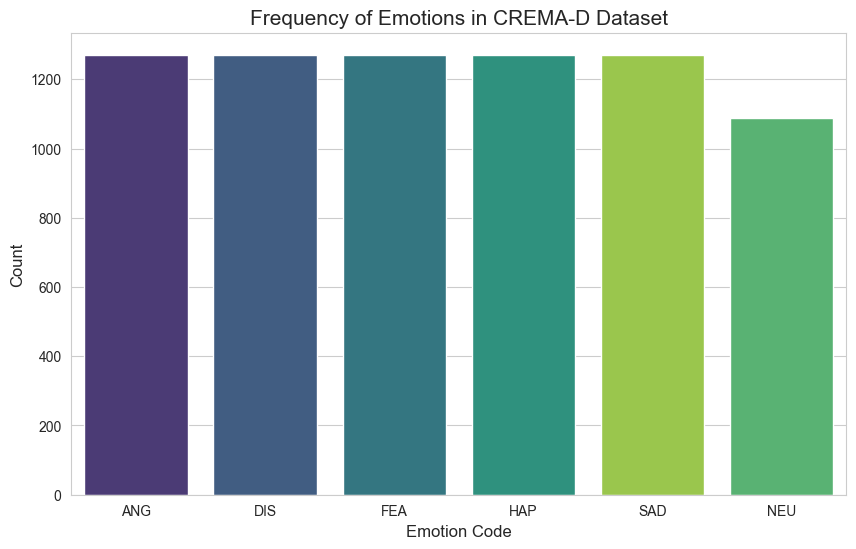

Total samples found: 7442


In [6]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the path and list files
data_path = "./data/CREMA-D"
files = [f for f in os.listdir(data_path) if f.endswith('.wav')]

# 2. Extract emotions (the 3rd part of the filename)
# Format: 1001_DFA_ANG_XX.wav -> ['1001', 'DFA', 'ANG', 'XX']
emotions = [f.split('_')[2] for f in files]

# 3. Create a DataFrame for easy plotting
df = pd.DataFrame(emotions, columns=['Emotion'])

# 4. Generate the histogram
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.countplot(data=df, x='Emotion', palette='viridis', order=df['Emotion'].value_counts().index, hue='Emotion', legend=False)

plt.title('Frequency of Emotions in CREMA-D Dataset', fontsize=15)
plt.xlabel('Emotion Code', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

print(f"Total samples found: {len(df)}")

# 2. Preprocessing
Pad or truncate the audio clips to 3 seconds and convert them to Mel Spectrograms.


In [ ]:
import os
import librosa
import numpy as np
from tqdm import tqdm

# Setup paths
data_path = "./data/CREMA-D"
save_path = "./features/mel_spectrograms"
os.makedirs(save_path, exist_ok=True)

# Target length: 3 seconds at 16kHz sample rate
TARGET_SR = 16000
TARGET_LENGTH = TARGET_SR * 3 

def process_and_save():
    files = [f for f in os.listdir(data_path) if f.endswith('.wav')]
    
    print(f"Processing {len(files)} files...")
    for f in tqdm(files):
        file_path = os.path.join(data_path, f)
        
        # Load audio
        y, sr = librosa.load(file_path, sr=TARGET_SR)
        
        # Pad or truncate to ensure uniform length
        if len(y) > TARGET_LENGTH:
            y = y[:TARGET_LENGTH]
        else:
            padding = TARGET_LENGTH - len(y)
            y = np.pad(y, (0, padding), 'constant')
            
        # Generate Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Normalize between 0 and 1 for the neural network
        mel_normalized = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min())
        
        # Save as a numpy array
        save_name = f.replace('.wav', '.npy')
        np.save(os.path.join(save_path, save_name), mel_normalized)

if __name__ == "__main__":
    print("Uncomment the lines below to process and save the spectrograms.")
    # process_and_save()
    # print("Spectrograms saved successfully!")